In [3]:
import numpy as np
from matplotlib import pyplot as plt
import math, copy

# Training data
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])

#compute cost function
def compute_cost (x,y,w,b):
    m = x.shape[0]
    cost_sum = 0
    for i in range(m):
        f_wb = w*x[i]+ b #prediction formula
        cost=(f_wb - y[i]) ** 2#cost function formula

    cost_sum = cost_sum + cost
    total_cost = cost_sum /(2*m)
    return total_cost


#compute the gradient
def compute_gradient(x, y, w, b):
###how many training examples are there    
    m = x.shape[0]
###bin to add each iteration gradient    
    dj_dw = 0
    dj_db = 0
### loop for each training example iteration 
    for i in range(m):
###Calculating the prediction     
     f_wb = (w * x[i] + b)
###Calculating Gradient
     dj_dw_i = (f_wb - y[i])*x[i]
     dj_db_i = f_wb - y[i]
###Adding to the bins
     dj_dw += dj_dw_i
     dj_db += dj_db_i
###Average gradient
     dj_dw = dj_dw / m
     dj_db = dj_db / m
    return( dj_dw, dj_db)

#Compute Gradient Descent

def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
 J_history=[]
 p_history=[]

 w = w_in
 b = b_in

 for i in range(num_iters):
    dj_dw, dj_db= gradient_function(x,y,w,b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    if i<100000:
       
     J_history.append(cost_function(x,y,w,b))
     p_history.append([w,b])
    
    if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
 return w,b,J_history, p_history  

       
w_init = 0
b_init = 0
iterations = 10000
tmp_alpha =1.0e-2

w_final, b_final, J_hist, p_hist = gradient_descent (x_train, y_train, w_init, b_init, tmp_alpha, iterations, compute_cost, compute_gradient)

print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")



Iteration    0: Cost 5.89e+04  dj_dw: -5.750e+02, dj_db: -3.250e+02   w:  5.750e+00, b: 3.25000e+00
Iteration 1000: Cost 1.89e-01  dj_dw: -1.572e-01, dj_db:  2.776e-01   w:  1.963e+02, b: 1.06566e+02
Iteration 2000: Cost 8.11e-02  dj_dw: -1.030e-01, dj_db:  1.819e-01   w:  1.976e+02, b: 1.04302e+02
Iteration 3000: Cost 3.48e-02  dj_dw: -6.749e-02, dj_db:  1.192e-01   w:  1.984e+02, b: 1.02819e+02
Iteration 4000: Cost 1.50e-02  dj_dw: -4.422e-02, dj_db:  7.811e-02   w:  1.990e+02, b: 1.01847e+02
Iteration 5000: Cost 6.42e-03  dj_dw: -2.898e-02, dj_db:  5.118e-02   w:  1.993e+02, b: 1.01211e+02
Iteration 6000: Cost 2.76e-03  dj_dw: -1.899e-02, dj_db:  3.354e-02   w:  1.996e+02, b: 1.00793e+02
Iteration 7000: Cost 1.18e-03  dj_dw: -1.244e-02, dj_db:  2.198e-02   w:  1.997e+02, b: 1.00520e+02
Iteration 8000: Cost 5.08e-04  dj_dw: -8.153e-03, dj_db:  1.440e-02   w:  1.998e+02, b: 1.00341e+02
Iteration 9000: Cost 2.18e-04  dj_dw: -5.343e-03, dj_db:  9.436e-03   w:  1.999e+02, b: 1.00223e+02


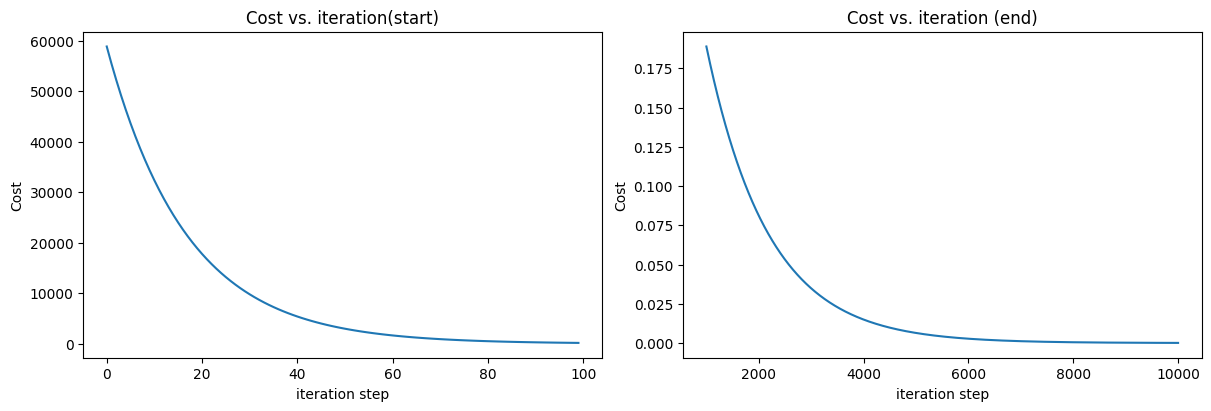

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:])
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)")
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step')
plt.savefig('Cost vs Iteration before and after') 
plt.show()

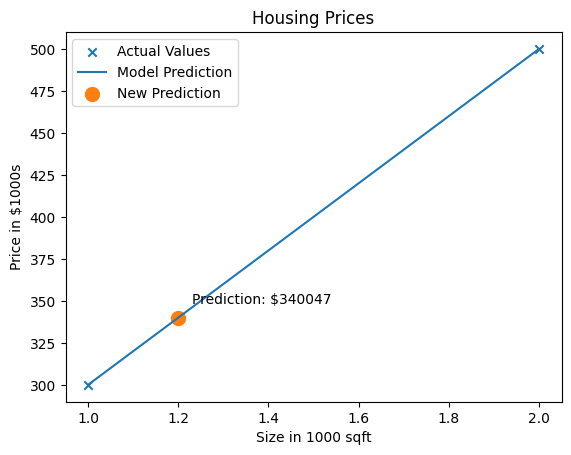

In [8]:
predictions = w_final * x_train + b_final
# 9. Make a new prediction

x_i = 1.2  # 1200 sqft
prediction = w_final * x_i + b_final

plt.scatter(x_train, y_train, marker="x", label="Actual Values")
plt.plot(x_train, predictions, label="Model Prediction")
# Plot new prediction as a marker
plt.scatter(x_i, prediction, marker="o", s=100, label="New Prediction")

# Optional: label the prediction point
plt.annotate(
    f"Prediction: ${prediction * 1000:.0f}",
    (x_i, prediction),
    textcoords="offset points",
    xytext=(10, 10)
)

plt.title("Housing Prices")
plt.xlabel("Size in 1000 sqft")
plt.ylabel("Price in $1000s")
plt.legend()
plt.savefig('Prediction for house Pricing')
plt.show()